In [1]:
import xarray as xr
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

In [2]:
subbasin_id= 58208

# Results directory
results_directory = './v10_1_results/'

geodata= pd.read_csv('../model_v10_1/GeoData.txt', index_col=0, sep='\t')

smrib_historical_path= '../../SMM_Models/hype/model/v10_model/final_model/old_hds_v1/results/0058208.txt'

# Define start and end date
start_date = "1981-10-01"
end_date = "2014-12-30"

# Select the variables to plot
variables_to_plot = ["upcprc", "upevap", "cout"]

In [3]:
def extract_ensemble(results_directory: str, subbasin_id: str ,start_date,end_date, exclude_members=True ):
    """
    Extracts ensemble data from files, filters by subbasin ID, and optionally excludes members not found in the offical ensemble.

    Parameters:
        results_directory (str): Path to the directory containing result files.
        subbasin_id (str): Identifier for filtering files belonging to a specific subbasin.
        exclude_members (bool): If True, excludes specified model members.

    Returns:
        xarray.DataArray: Combined ensemble data as an xarray DataArray.
    """
    # List of model names to exclude (not in official ensemble)
    exclude_models = [
        'CanESM5', 'CNRM-CM6-1', 'EC-Earth3', 'IPSL-CM6A-LR',
        'UKESM1-0-LL', 'NorESM2-MM', 'EC-Earth3-CC', 'NESM3',
        'EC-Earth3-Veg', 'INM-CM4-8', 'TaiESM1'
    ]
    
    # Check for files of required subbasin_id
    file_list = [os.path.join(results_directory, filename) for filename in os.listdir(results_directory)
                 if subbasin_id in filename]  # Only filter by subbasin_id
    
    # Create an empty list to store xarray DataArrays
    data_arrays: List[xr.DataArray] = []
    member_names = []  # To store the 'name' of each DataArray for concatenation

    # Loop through each file
    for file_path in file_list:
        # Extract the filename without extension to use as the member name
        member_name = os.path.splitext(os.path.basename(file_path))[0]

        # Conditionally exclude models if exclude_members is True
        if exclude_members and (any(excluded in member_name for excluded in exclude_models) or 'ssp585' in member_name):
            continue
        
        # Read the file into a pandas DataFrame
        df = pd.read_csv(file_path, sep='\t', index_col=0, low_memory=False)

        # Drop the first row to remove units
        df = df.iloc[1:]
        
     #   df= df[[variable]]

        # Convert the DataFrame to an xarray DataArray
        data_array = xr.DataArray(df.values, dims=('DATE', 'variable'),
                                  coords={'DATE': df.index, 'variable': df.columns})
        
        # Assign the filename as the name of the DataArray
        data_array.name = member_name
        
        # Append the DataArray to the list
        data_arrays.append(data_array)
        member_names.append(member_name)  # Keep track of the member name

    # Check if any valid data arrays exist
    if not data_arrays:
        return xr.DataArray()  # Return an empty DataArray if no valid members are left
    
    # Concatenate the list of DataArrays along dimension 'member'
    ds = xr.concat(data_arrays, dim='member')
    
    # Add the member names as a coordinate
    ds.coords['member'] = ('member', member_names)

    # Convert 'DATE' coordinate to datetime, specifying the format and handling errors
    ds['DATE'] = pd.to_datetime(ds['DATE'], format='%Y-%m-%d', errors='coerce')


    # Trim dataset
    ds_trimmed = ds.sel(DATE=slice(start_date, end_date))
    
    return ds_trimmed

In [4]:
def process_historical(filepath: str, start_date: str = '1981-01-01', end_date: str = '2015-12-31') -> pd.DataFrame:
    """
    Processes historical data from HYPE output files into an average annual timeseries for all variables.

    Parameters:
        filepath (str): Path to the HYPE output file.
        start_date (str): The start date for the data filter (default is '1981-01-01').
        end_date (str): The end date for the data filter (default is '2015-12-31').

    Returns:
        pd.DataFrame: A pandas DataFrame with the historical average annual timeseries for all variables.
    """
    
    # Read the tab-separated text file into a DataFrame
    sim: pd.DataFrame = pd.read_csv(filepath, delimiter='\t', index_col=0, low_memory=False)
    
    # Drop the first row
    sim = sim.iloc[1:]
    
    # Convert index to datetime
    sim.index = pd.to_datetime(sim.index)
    
    # Trim the DataFrame between dates
    sim = sim.loc[start_date:end_date]
    
    # Convert all columns to numeric
    sim = sim.apply(pd.to_numeric, errors='coerce')
    
    # Replace -9999 values with NaN for all columns
    sim = sim.replace(-9999, pd.NA)
    
    return sim


In [5]:
# Create a dictionary to map variables to corresponding names and units
variable_dict = {
    'cout': {'name': 'Runoff', 'unit': 'mm'},
    'cloc': {'name': 'Runoff from Subbasin', 'unit': 'm3'},
    'evap': {'name': 'Evapotranspiration', 'unit': 'mm'},
    'cprc': {'name': 'Precipitation', 'unit': 'mm'},
    'upsnow': {'name': 'Mean Upstream SWE', 'unit': 'mm'},
    'upsoim': {'name': 'Mean Upstream Soil Moisture', 'unit': 'mm'},
    'upcprc': {'name': 'Mean Upstream Precipitation', 'unit': 'mm'},
    'upctmp': {'name': 'Mean Upstream Temperature', 'unit': 'C'},
    'upevap': {'name': 'Mean Upstream Evapotranspiration', 'unit': 'mm'}
}

### Upstream Segments

In [6]:
start_datetime = pd.to_datetime(start_date)
end_datetime = pd.to_datetime(end_date)

days_between = (end_datetime - start_datetime).days

In [7]:
# Convert columns to string data type
geodata['maindown'] = geodata['maindown'].astype(int)
geodata.index= geodata.index.astype(int)

# Create a dictionary with subbasin ID and area
subbasin_area = geodata["area"].to_dict()

In [8]:
# Assuming `geodata` is already defined
# Create a directed graph
riv_graph = nx.DiGraph()

# Add edges from DataFrame
for idx, row in geodata.iterrows():
    if row['maindown'] != '0':  # Skip if maindown is '0'
        riv_graph.add_edge(idx, row['maindown'])

# Find upstream segments for the given segment
upstream_segments = list(nx.ancestors(riv_graph, subbasin_id))

# Add the target segment 'riv_seg' to the upstream segments
upstream_segments.append(subbasin_id)

print(f'{subbasin_id}: {upstream_segments}')

58208: [58241, 58210, 58212, 58213, 58214, 58216, 58219, 58221, 58223, 58227, 58232, 58233, 58237, 58208]


In [9]:
# Sum the areas for the upstream segments
total_area = sum(subbasin_area[seg] for seg in upstream_segments if seg in subbasin_area)

### Process Info

In [10]:
stm_official_ensemble= extract_ensemble(results_directory, '58208', start_date, end_date, True)

In [11]:
smrib_historical= process_historical(smrib_historical_path, start_date, end_date)

### RDRS

In [ ]:
smrib_historical = smrib_historical.filter(items=variables_to_plot)

smrib_historical['cout'] = ((smrib_historical['cout'] * 86400) / total_area) * 1000 # convert to m/day then mm/day

In [12]:
smrib_historical = smrib_historical.filter(items=variables_to_plot)

smrib_historical['cout'] = ((smrib_historical['cout'] * 86400) / total_area) * 1000 # convert to m/day then mm/day

cumulative_hist = smrib_historical.cumsum()

cumulative_hist = cumulative_hist.rename(columns=str)

### Ouranos

In [13]:
# Select only the specified variables
stm_official_ensemble = stm_official_ensemble.sel(variable=variables_to_plot).astype(float)

In [14]:
stm_official_ensemble.loc[dict(variable="cout")] *= (86400 / total_area) * 1000

In [15]:
# Find cumulative sum of each var
stm_official_ensemble_cummulative = stm_official_ensemble.cumsum(dim="DATE")

# Extract final time step
official_final_values = stm_official_ensemble_cummulative.isel(DATE=-1)

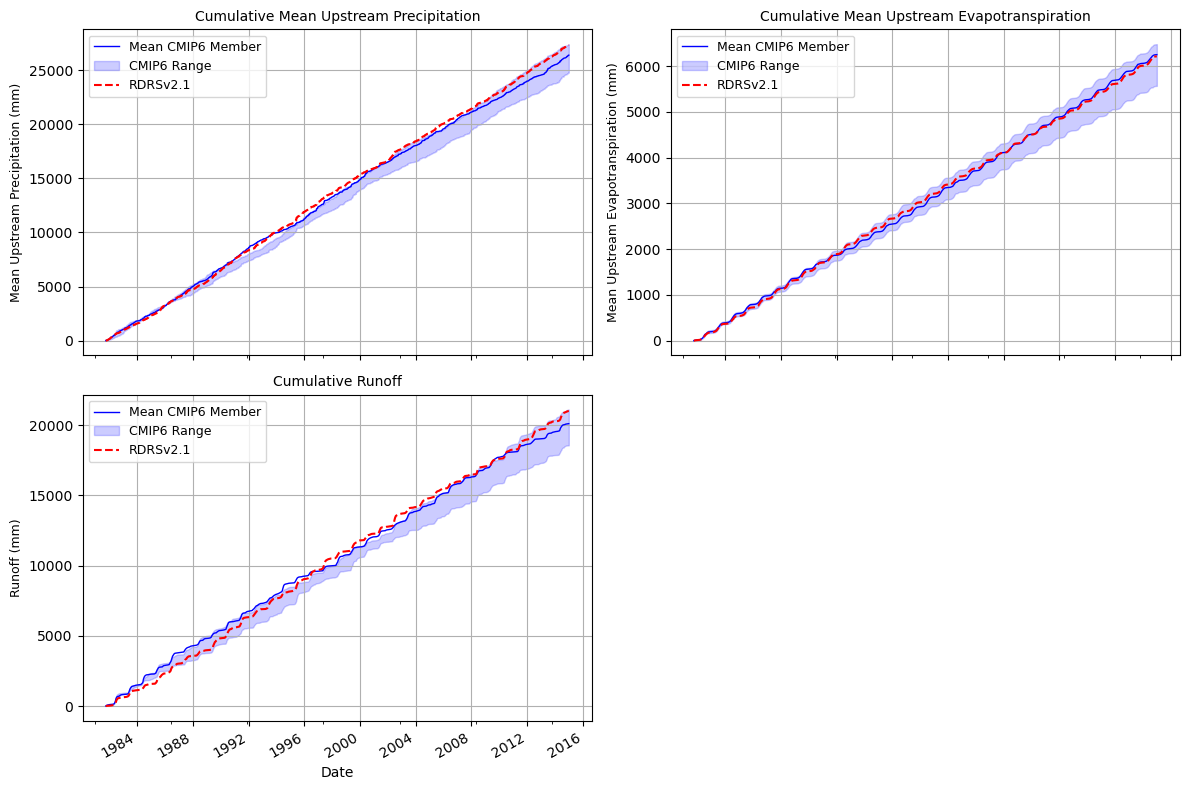

In [16]:
# Create a 2-column layout for subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8), sharex=True)

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Loop through each variable and plot
for i, var in enumerate(variables_to_plot):
    # Extract the variable name and unit from the dictionary
    variable_name = variable_dict[var]['name']
    variable_unit = variable_dict[var]['unit']

    # Find member with max cumulative var
    max_member_var = official_final_values.sel(variable=var).member[
        official_final_values.sel(variable=var).argmax(dim="member")
    ]

    max_member_str = max_member_var.item()

    # Find member with min cumulative var
    min_member_var = official_final_values.sel(variable=var).member[
        official_final_values.sel(variable=var).argmin(dim="member")
    ]

    min_member_str = min_member_var.item()

    # Find the member best representing the mean
    official_final_values_var = official_final_values.sel(variable=var)
    mean_value_var = official_final_values_var.mean(dim="member")
    closest_mean_member_var = official_final_values_var.member[
        np.abs(official_final_values_var - mean_value_var).argmin(dim="member")
    ]

    mean_member_str = closest_mean_member_var.item()

    # Extract data for min, max, and closest-to-mean members
    min_values = stm_official_ensemble_cummulative.sel(member=min_member_str, variable=var)
    max_values = stm_official_ensemble_cummulative.sel(member=max_member_str, variable=var)
    mean_values = stm_official_ensemble_cummulative.sel(member=mean_member_str, variable=var)
    
    # Plot closest-to-mean member as a solid blue line
    mean_values.plot(ax=axes[i], color="b", linewidth=1, label="Mean CMIP6 Member")
    
    # Plot shaded region between min and max members
    axes[i].fill_between(mean_values.DATE, min_values, max_values, color="b", alpha=0.2, label="CMIP6 Range")
    
    # Check if the variable exists in cumulative_hist and plot it
    if var in cumulative_hist:
        cumulative_hist[var].plot(ax=axes[i], color="r", linestyle="--", linewidth=1.5, label="RDRSv2.1")

    # Set the title and y-axis label using the variable's name and unit
    axes[i].set_title(f"Cumulative {variable_name}", fontsize=10)
    axes[i].set_ylabel(f"{variable_name} ({variable_unit})", fontsize=9)
    axes[i].grid(True)
    
    # Add a legend to each plot with fontsize
    axes[i].legend(fontsize=9)

# Remove the empty subplot if there are fewer than 4 variables
fig.delaxes(axes[-1])

# Set common x-axis label
axes[-2].set_xlabel("Date", fontsize=10)
axes[-1].set_xlabel("Date", fontsize=10)

# Adjust layout
plt.tight_layout()
plt.show()

In [20]:
# List to store results
member_values_list = []

# Loop through each variable
for var in variables_to_plot:

    # Extract the variable name and unit from the dictionary
    variable_name = variable_dict[var]['name']
    variable_unit = variable_dict[var]['unit']

    # Find max, min, and closest-to-mean members
    max_member_var = official_final_values.sel(variable=var).member[
        official_final_values.sel(variable=var).argmax(dim="member")
    ].item()

    min_member_var = official_final_values.sel(variable=var).member[
        official_final_values.sel(variable=var).argmin(dim="member")
    ].item()

    # Compute mean value across members
    mean_value_var = official_final_values.sel(variable=var).mean(dim="member")

    # Find member closest to the mean
    closest_mean_member_var = official_final_values.sel(variable=var).member[
        np.abs(official_final_values.sel(variable=var) - mean_value_var).argmin(dim="member")
    ].item()

    # Extract values for max, min, and mean members
    if var == "cloc":  # Check if variable is 'cloc'
        max_value = f"{official_final_values.sel(variable=var, member=max_member_var).item():.2e}"
        min_value = f"{official_final_values.sel(variable=var, member=min_member_var).item():.2e}"
        mean_value = f"{official_final_values.sel(variable=var, member=closest_mean_member_var).item():.2e}"
    else:  # For other variables, use 1f format
        max_value = f"{official_final_values.sel(variable=var, member=max_member_var).item():.0f}"
        min_value = f"{official_final_values.sel(variable=var, member=min_member_var).item():.0f}"
        mean_value = f"{official_final_values.sel(variable=var, member=closest_mean_member_var).item():.0f}"

    # Extract the last value of cumulative_hist[var] (if it exists)
    if var in cumulative_hist:
        if var == "cloc":  # Apply 2e formatting for 'cloc'
            last_hist_value = f"{cumulative_hist[var].iloc[-1]:.2e}"
        else:  # Apply 1f formatting for other variables
            last_hist_value = f"{cumulative_hist[var].iloc[-1]:.0f}"
    else:
        last_hist_value = None  # If var is not in cumulative_hist

    # Append results to list with formatted values
    member_values_list.append({
        "Variable":  f"{variable_name} ({variable_unit})",
        "RDRSv2.1": last_hist_value,  # Store last cumulative_hist value
        "Max CMIP6 Member": max_value,
        "Min CMIP6 Member": min_value,
        "Mean CMIP6 Member": mean_value
    })

# Convert to DataFrame and set Variable as the index
df_member_values = pd.DataFrame(member_values_list).set_index("Variable")

# Ensure required variables exist before calculations
runoff_var = "Runoff (mm)"
precip_var = "Mean Upstream Precipitation (mm)"
et_var = "Mean Upstream Evapotranspiration (mm)"

if all(var in df_member_values.index for var in [runoff_var, precip_var, et_var]):
    # Convert values to numeric
    df_member_values.loc[runoff_var] = pd.to_numeric(df_member_values.loc[runoff_var], errors="coerce")
    df_member_values.loc[precip_var] = pd.to_numeric(df_member_values.loc[precip_var], errors="coerce")
    df_member_values.loc[et_var] = pd.to_numeric(df_member_values.loc[et_var], errors="coerce")

    # Compute Runoff Ratio and ET Ratio
    df_member_values.loc["Runoff Ratio"] = df_member_values.loc[runoff_var] / df_member_values.loc[precip_var]
    df_member_values.loc["ET Ratio"] = df_member_values.loc[et_var] / df_member_values.loc[precip_var]

    # Format only the new rows to 2 decimal places
    df_member_values.loc[["Runoff Ratio", "ET Ratio"]] = df_member_values.loc[["Runoff Ratio", "ET Ratio"]].map(
        lambda x: f"{x:.2f}" if pd.notna(x) else x
    )

# Display table
df_member_values

,RDRSv2.1,Max CMIP6 Member,Min CMIP6 Member,Mean CMIP6 Member
Variable,,,,
Mean Upstream Precipitation (mm),27332,27401,24774,26384
Mean Upstream Evapotranspiration (mm),6214,6481,5569,6252
Runoff (mm),21028,21122,18573,20113
Runoff Ratio,0.77,0.77,0.75,0.76
ET Ratio,0.23,0.24,0.22,0.24
